In [ ]:
!pip  install numpy pandas matplotlib seaborn scikit-learn tensorflow

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving online_shoppers_intention.csv to online_shoppers_intention.csv


In [ ]:
df = pd.read_csv("online_shoppers_intention.csv")
print("First 15 rows")
df.head(15)

First 15 rows


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [ ]:
print("Last 5 row")
df.tail()

Last 5 row


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [ ]:
df.columns.tolist()

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend',
 'Revenue']

In [ ]:
print('Data types')
df.dtypes

Data types


,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [ ]:
print('Dataset Info')
df.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficTy

In [ ]:
print('Summary statistics for numeric columns')
display(df.describe().T)

print('Summary statistics for categorical columns')
display(df.describe(include='object'))

Summary statistics for numeric columns


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


Summary statistics for categorical columns


,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


In [ ]:
df.isna().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [ ]:
df.duplicated().sum()


np.int64(125)

In [ ]:
df[df.duplicated()]

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
418,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
456,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,4,1,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12180,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,13,9,20,Returning_Visitor,False,False


Target Variable

In [ ]:
revenue = df['Revenue'].value_counts()
print(revenue)

Revenue
False    10422
True      1908
Name: count, dtype: int64


In [ ]:
rev_percent = df['Revenue'].value_counts(normalize= True) * 100
print(rev_percent)

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


/tmp/ipykernel_3271/1307071303.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Revenue', palette='pastel')


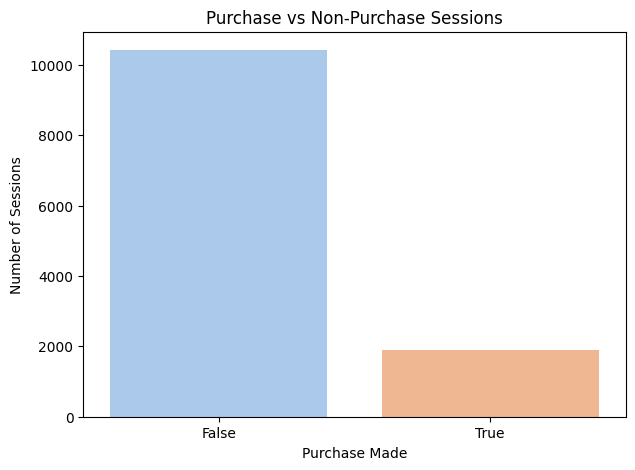

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Revenue', palette='pastel')

plt.title('Purchase vs Non-Purchase Sessions')
plt.xlabel('Purchase Made')
plt.ylabel('Number of Sessions')

plt.show()



From the graph, we can observe that:

*   **Non-Purchase Sessions (False)**: There are `10422` sessions where no purchase was made, accounting for approximately `84.53%` of the total sessions.
*   **Purchase Sessions (True)**: There are `1908` sessions where a purchase was made, accounting for approximately `15.47%` of the total sessions.

This indicates that the target variable is  imbalanced, with a much higher number of non-purchase sessions compared to purchase sessions in the dataset.

##Univariable Analysis
#Visitors


In [ ]:
print('Number of Visitors')
df['VisitorType'].value_counts()

Number of Visitors


,count
VisitorType,
Returning_Visitor,10551
New_Visitor,1694
Other,85


In [ ]:
vis_percentage =df['VisitorType'].value_counts(normalize= True) * 100
print(vis_percentage)

VisitorType
Returning_Visitor    85.571776
New_Visitor          13.738848
Other                 0.689376
Name: proportion, dtype: float64


/tmp/ipykernel_3271/3409387411.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='VisitorType', palette='pastel')


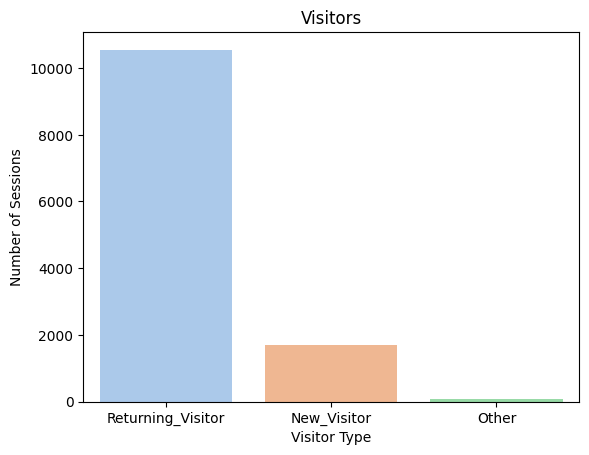

In [ ]:
sns.countplot(data=df, x='VisitorType', palette='pastel')

plt.title('Visitors')
plt.xlabel('Visitor Type')
plt.ylabel('Number of Sessions')

plt.show()

This graph displays the distribution of different visitor types to the website.

From the graph and the calculated percentages, we can observe the following:

*   **Returning Visitors**: There are `10551` returning visitors, making up approximately `85.57%` of the total sessions. This is the largest group, indicating a strong base of repeat users.
*   **New Visitors**: There are `1694` new visitors, accounting for about `13.74%` of the total sessions.
*   **Other**: A very small portion, `85` visitors, fall into the 'Other' category, representing approximately `0.69%` of the sessions.

The vast majority of sessions are from returning visitors, which suggests a need to focus on strategies that engage new visitors and convert them into returning customers, as well as optimizing the experience for the dominant returning visitor segment.

Product-Related Pages

In [ ]:
df['ProductRelated'].describe()

,ProductRelated
count,12330.000000
mean,31.731468
std,44.475503
min,0.000000
25%,7.000000
50%,18.000000
75%,38.000000
max,705.000000


/tmp/ipykernel_3271/1295178564.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


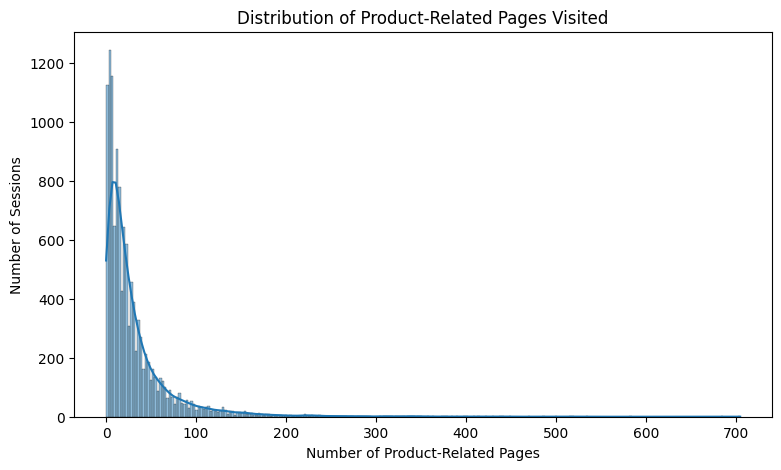

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x='ProductRelated',
    kde=True, palette='pastel'
)

plt.title('Distribution of Product-Related Pages Visited')
plt.xlabel('Number of Product-Related Pages')
plt.ylabel('Number of Sessions')

plt.show()



Key observations from the graph and descriptive statistics are:

*   **Highly Right-Skewed Distribution**: The distribution is heavily skewed to the right, indicating that most sessions involve viewing a relatively small number of product-related pages.
*   **Concentration at Lower Values**: A large majority of sessions (75%) visited 38 or fewer product-related pages. The median number of product-related pages visited is 18.
*   **Peak at Very Low Values**: The distribution shows a strong peak at the lower end, with many sessions visiting between 0 and 20 product-related pages.
*   **Wide Range and Outliers**: While most sessions involve fewer pages, there's a long tail extending up to 705 product-related pages, suggesting that a small number of users engage very deeply with product content, potentially indicating highly interested customers or browsing behavior.

Months

In [ ]:
months = [ 'Jan','Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


/tmp/ipykernel_3271/833830731.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Month', order= months, palette='pastel')


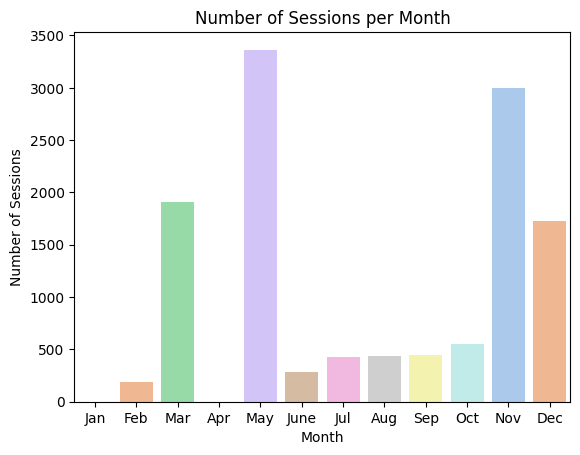

In [ ]:
month_conversion = pd.crosstab(
    df['Month'],
    df['Revenue'],
    normalize='index'
) * 100

month_conversion
sns.countplot(data=df, x='Month', order= months, palette='pastel')
plt.title('Number of Sessions per Month')
plt.xlabel('Month')
plt.ylabel('Number of Sessions')
plt.show()



Key observations from the graph are:

*   **Peak Months**: The highest number of sessions occur in May (over 3000 sessions) and November (around 3000 sessions), followed by March (around 1900 sessions) and December (around 1700 sessions). These months likely represent periods of high online activity, possibly due to seasonal shopping trends or promotions.
*   **Low Activity Months**: There is significantly lower activity in the early months of the year (January, February), and during the summer months (June, July, August, September, October), with June having the fewest sessions.
*   **Seasonal Trend**: The data suggests a clear seasonal pattern, with activity increasing towards the end of the year, particularly in the lead-up to holiday shopping seasons (November and December).

In [ ]:
df['ProductRelated_Duration'].describe()

,ProductRelated_Duration
count,12330.000000
mean,1194.746220
std,1913.669288
min,0.000000
25%,184.137500
50%,598.936905
75%,1464.157214
max,63973.522230


/tmp/ipykernel_589/704813487.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


Text(0, 0.5, 'Number of Sessions')

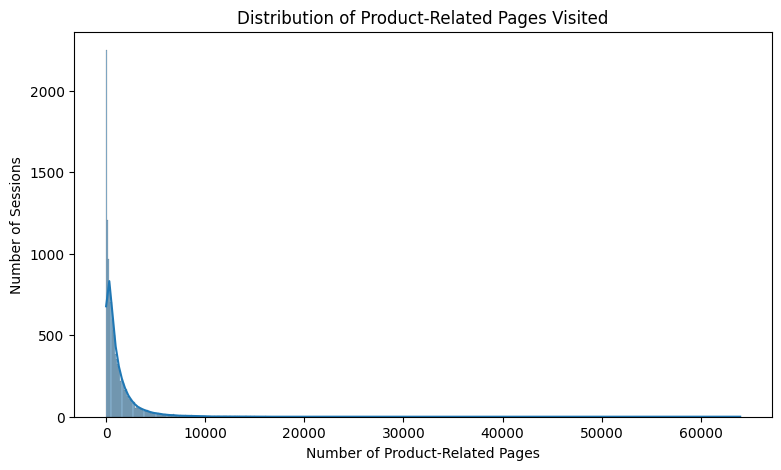

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
     x='ProductRelated_Duration',
    kde=True, palette='pastel'
)
plt.title('Distribution of Product-Related Pages Visited')
plt.xlabel('Number of Product-Related Pages')
plt.ylabel('Number of Sessions')



Key observations from the graph and descriptive statistics are:

*   **Highly Right-Skewed Distribution**: The distribution is heavily skewed to the right, indicating that most sessions involve viewing a relatively small number of product-related pages. This is evident from the tall bars on the left side of the histogram and a long tail extending to the right.
*   **Concentration at Lower Values**: A large majority of sessions (75%) visited 38 or fewer product-related pages. The median number of product-related pages visited is 18. This suggests that while some users browse extensively, most engagements are brief in terms of product page views.
*   **Peak at Very Low Values**: The distribution shows a strong peak at the lower end, with many sessions visiting between 0 and 20 product-related pages, highlighting quick browsing or direct navigation patterns.
*   **Wide Range and Outliers**: While most sessions involve fewer pages, there's a long tail extending up to 705 product-related pages, suggesting that a small number of users engage very deeply with product content, potentially indicating highly interested customers or detailed research behavior.

In [ ]:
df['BounceRates'].describe()

,BounceRates
count,12330.000000
mean,0.022191
std,0.048488
min,0.000000
25%,0.000000
50%,0.003112
75%,0.016813
max,0.200000


/tmp/ipykernel_3271/3638990907.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


Text(0, 0.5, 'Number of Sessions')

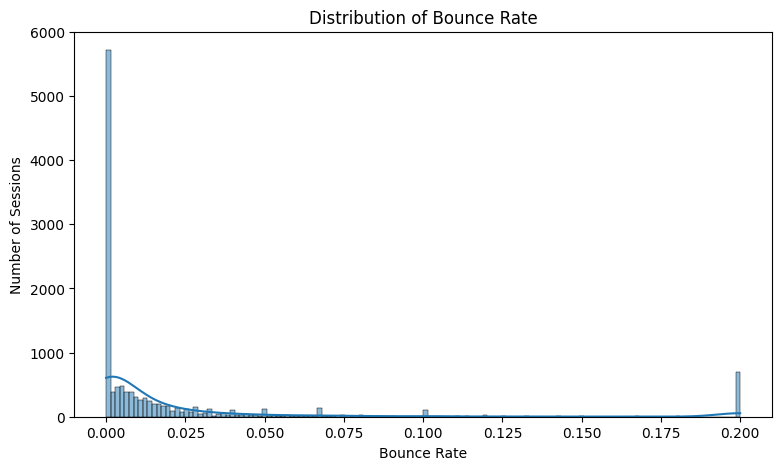

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x='BounceRates',
    kde=True, palette='pastel'
)
plt.title('Distribution of Bounce Rate')
plt.xlabel('Bounce Rate')
plt.ylabel('Number of Sessions')

Key observations from the graph and descriptive statistics are:

*   **Highly Right-Skewed Distribution**: The distribution is heavily skewed to the right, with a very strong peak near zero bounce rate. This indicates that a large majority of sessions have very low bounce rates.
*   **Concentration at Lower Values**: Most sessions exhibit extremely low bounce rates. The median bounce rate is approximately 0.0031 (0.31%), and 75% of sessions have a bounce rate of 0.0168 (1.68%) or less.
*   **Peak at Zero**: There is a significant number of sessions where the bounce rate is exactly zero, suggesting that many users engage beyond the initial page.
*   **Outliers/High Bounce Rates**: While the majority have low bounce rates, there's also a noticeable peak at the maximum bounce rate of 0.20 (20%). This indicates a subset of sessions where users immediately leave the website, which could be due to various reasons such as irrelevant landing pages or users quickly finding what they need and leaving.

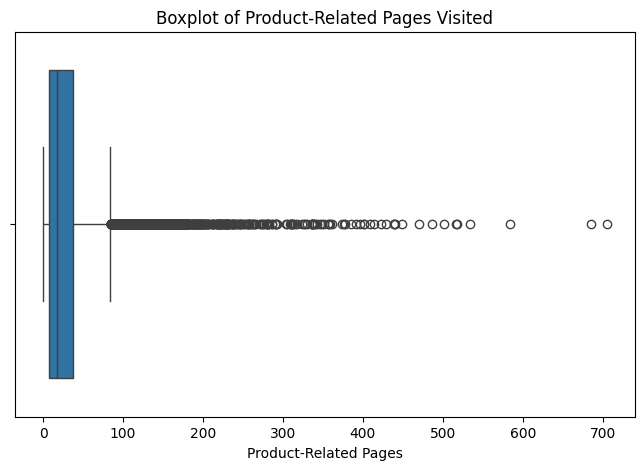

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='ProductRelated')

plt.title('Boxplot of Product-Related Pages Visited')
plt.xlabel('Product-Related Pages')

plt.show()

Key observations from the boxplot and descriptive statistics are:

*   **Median**: The median (the line inside the box) is at 18, indicating that 50% of sessions involved visiting 18 or fewer product-related pages.
*   **Interquartile Range (IQR)**: The box itself spans from 7 (25th percentile) to 38 (75th percentile). This means that the middle 50% of sessions viewed between 7 and 38 product-related pages.
*   **Right Skewness**: The median line is closer to the bottom of the box, and the whisker extends much further to the right than to the left, indicating a strong right-skewed distribution. This means most sessions involve a lower number of product-related page views, with fewer sessions having a very high number.
*   **Outliers**: There are many individual points plotted far to the right of the upper whisker. These represent outliers, indicating a significant number of sessions where users visited an unusually high number of product-related pages (up to 705 pages, as seen in the describe output). These could be highly engaged users or automated activity.

##BIVARIABLE ANALYSIS

#1.Visitor Type vs Revenue

Does the type of visitor relate to whether they make a purchase?

In [ ]:
pd.crosstab(df['VisitorType'], df['Revenue'],normalize='index' )*100

Revenue,False,True
VisitorType,,
New_Visitor,75.088548,24.911452
Other,81.176471,18.823529
Returning_Visitor,86.067671,13.932329


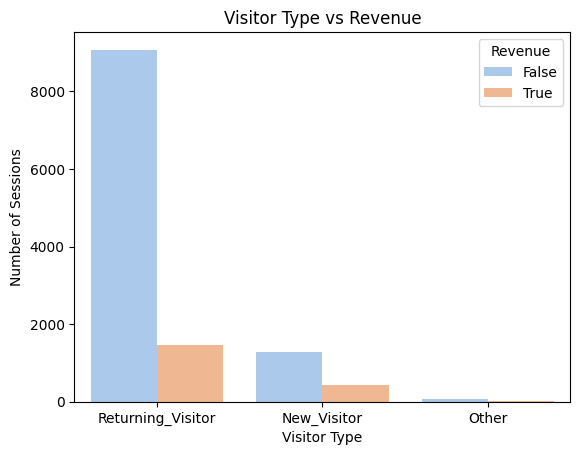

In [ ]:
sns.countplot(data=df, x='VisitorType', hue='Revenue', palette='pastel')

plt.title('Visitor Type vs Revenue')
plt.xlabel('Visitor Type')
plt.ylabel('Number of Sessions')

plt.show()

Here's an explanation of the 'Visitor Type vs Revenue' graph:

This graph illustrates the relationship between the type of visitor and whether they generate revenue, alongside the `pd.crosstab` analysis providing proportional breakdowns.

Key observations from the graph and analysis are:

*   **Returning Visitors**: This group accounts for the largest number of both non-revenue (approximately 73.65% of total sessions) and revenue-generating sessions (approximately 11.92% of total sessions). In absolute terms, around 1470 revenue-generating sessions come from returning visitors. Their conversion rate is about 13.93%.
*   **New Visitors**: New visitors contribute a smaller proportion to total sessions but show a higher conversion rate. They account for about 10.32% of non-revenue sessions and 3.42% of revenue-generating sessions. In absolute terms, around 422 revenue-generating sessions come from new visitors. Their conversion rate is notably higher at about 24.91%.
*   **Other Visitors**: This is a very small category, with minimal contribution to both non-revenue (0.56%) and revenue-generating (0.13%) sessions. Their conversion rate is about 18.82%.

**Implications**:

While returning visitors contribute the most to the *absolute number* of purchases, new visitors exhibit a significantly *higher conversion rate*. Returning visitors make up the vast majority of sessions, while new visitors represent a substantially smaller proportion of website traffic. This could imply effective first-impression strategies or that new visitors might be actively searching for specific items to buy. For returning visitors, the challenge might be to increase their conversion rate despite their high overall traffic volume.

#2. ProductRelated vs Revenue

In [ ]:
pd.crosstab(df['ProductRelated'], df['Revenue'],normalize='index' )*100

Revenue,False,True
ProductRelated,,
0,84.210526,15.789474
1,97.909968,2.090032
2,95.698925,4.301075
3,94.541485,5.458515
4,95.544554,4.455446
...,...,...
518,100.000000,0.000000
534,0.000000,100.000000
584,100.000000,0.000000


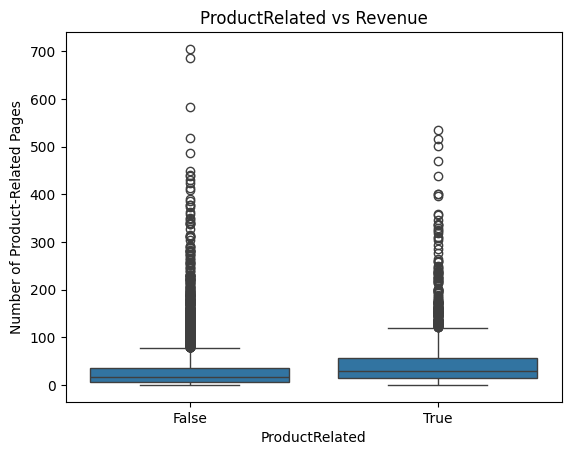

In [ ]:
sns.boxplot(
    data=df,
    x='Revenue',
    y='ProductRelated'
)

plt.title('ProductRelated vs Revenue')
plt.xlabel('ProductRelated')
plt.ylabel('Number of Product-Related Pages')

plt.show()


Key observations from the graph :

*   **Sessions without Revenue (False)**:
    *   The median number of product-related pages visited for non-revenue sessions appears to be quite low, roughly around 15-20 pages. The interquartile range (the box) is also relatively compact, suggesting that most non-converting sessions involve a limited number of product-related page views.
    *   Despite the low median, there's a long tail of outliers extending to very high numbers of product-related page visits (up to 700+ pages). This indicates that some users browse many product pages but still don't make a purchase.

*   **Sessions with Revenue (True)**:
    *   The median number of product-related pages visited for revenue-generating sessions is noticeably higher than for non-revenue sessions, roughly around 30-40 pages. This suggests that users who make a purchase tend to explore more product pages.
    *   The interquartile range (the box) for revenue sessions also appears wider and shifted upwards compared to non-revenue sessions, indicating a greater and more varied engagement with product content among converting users.
    *   Similar to non-revenue sessions, there are numerous outliers, with some converting sessions involving an extremely high number of product-related page views. This implies that some customers do extensive research before buying.

**Overall Implication**:

There is a clear positive correlation between the number of product-related pages visited and the likelihood of a session generating revenue. Sessions that result in a purchase generally involve more product-related page views, as indicated by the higher median and shifted-upward box for 'True' revenue sessions. However, the presence of many outliers in both categories suggests that while increased engagement with product pages is a good indicator, it's not a sole determinant of conversion.

#3. Month vs Revenue

In [ ]:
pd.crosstab(df['Month'], df['Revenue'],normalize='index' )*100

Revenue,False,True
Month,,
Aug,82.448037,17.551963
Dec,87.492762,12.507238
Feb,98.369565,1.630435
Jul,84.722222,15.277778
June,89.930556,10.069444
Mar,89.931830,10.068170
May,89.149822,10.850178
Nov,74.649767,25.350233
Oct,79.052823,20.947177


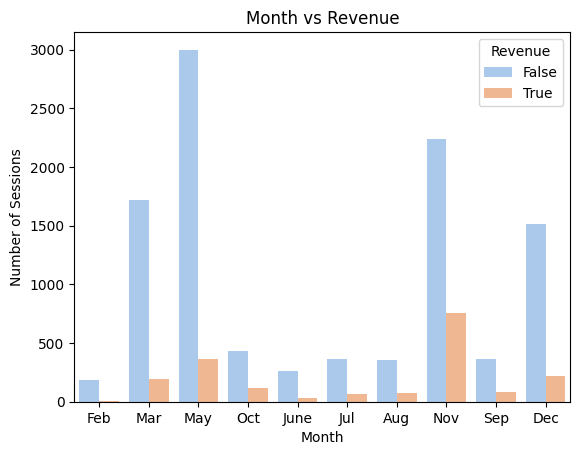

In [ ]:
sns.countplot(data=df, x='Month', hue='Revenue', palette='pastel')

plt.title('Month vs Revenue')
plt.xlabel('Month')
plt.ylabel('Number of Sessions')

plt.show()

This graph illustrates the relationship between the month in which a session occurred and whether that session generated revenue, complemented by the `pd.crosstab` analysis providing proportional breakdowns.

Key observations from the graph and analysis are:

*   **High Activity and Revenue Months**: November stands out with the highest number of revenue-generating sessions, followed by May, March, and December. These months likely correspond to peak shopping seasons or promotional periods.
    *   **November**: Accounts for the highest percentage of revenue (`6.16%`) and a significant portion of non-revenue (`18.15%`) sessions. This indicates a very high volume of activity, with a good conversion rate.
    *   **May**: Has a very high number of total sessions, contributing `2.96%` to revenue and `24.32%` to non-revenue sessions. While total sessions are high, the proportion of revenue compared to non-revenue is lower than November, suggesting a potentially lower conversion rate in absolute terms for this month.
    *   **March and December**: Also show considerable revenue generation, with March contributing `1.56%` revenue and `13.91%` non-revenue, and December contributing `1.75%` revenue and `12.25%` non-revenue.

*   **Low Activity and Revenue Months**: February, June, July, August, September, and October generally show lower numbers of both non-revenue and revenue-generating sessions compared to the peak months. February has particularly low revenue generation (`0.02%`).

*   **Conversion Rate Insights**: While some months like November have both high traffic and high revenue, other months like May have high traffic but a lower *proportion* of revenue compared to the total sessions for that month. This suggests that the *efficiency* of converting sessions into revenue might vary by month.

**Overall Implication**:

The data clearly shows seasonal patterns in both website traffic and revenue generation. Marketing and sales efforts could be intensified during high-potential months like November, May, March, and December, and strategies to improve conversion rates in high-traffic but lower-conversion months could be explored. The vast difference in activity across months highlights the importance of seasonal planning for e-commerce businesses.

#4. ExitRates vs Revenue

In [ ]:
pd.crosstab(df['ExitRates'], df['Revenue'],normalize= 'index')*100

Revenue,False,True
ExitRates,,
0.000000,55.263158,44.736842
0.000176,100.000000,0.000000
0.000250,100.000000,0.000000
0.000262,100.000000,0.000000
0.000263,100.000000,0.000000
...,...,...
0.183333,100.000000,0.000000
0.186667,100.000000,0.000000
0.188889,100.000000,0.000000


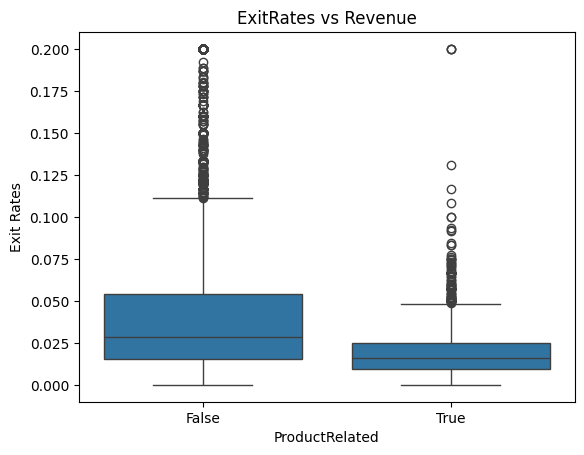

In [ ]:
sns.boxplot(
    data=df,
    x='Revenue',
    y='ExitRates'
)

plt.title('ExitRates vs Revenue')
plt.xlabel('ProductRelated')
plt.ylabel('Exit Rates')

plt.show()



Key observations from the boxplot and analysis are:

*   **Sessions without Revenue (False)**:
    *   The boxplot for non-revenue sessions shows a generally higher distribution of Exit Rates. The median exit rate (the line inside the box) is relatively high, and the interquartile range (the box itself) indicates that a significant portion of these sessions have higher exit rates.
    *   Many outliers extend to very high exit rates, indicating numerous sessions where users left the site quickly without converting.
    *   The `pd.crosstab` also shows that a large proportion of sessions with high exit rates (e.g., 0.200000) are associated with `False` revenue (5.73%).

*   **Sessions with Revenue (True)**:
    *   In contrast, the boxplot for revenue-generating sessions shows a significantly lower distribution of Exit Rates. The median exit rate is much lower, and the interquartile range is also compressed and shifted downwards.
    *   This indicates that users who ultimately make a purchase tend to have much lower exit rates, meaning they spend more time on the site and navigate through more pages before leaving.
    *   While there are still some outliers with higher exit rates, they are less frequent and generally lower than those in the non-revenue category.
    *   Conversely, the `pd.crosstab` reveals that a significant percentage of sessions with very low exit rates (e.g., 0.000000) contribute to `True` revenue (0.27%).

**Overall Implication**:

There is a clear inverse relationship between Exit Rates and revenue generation. Sessions with lower exit rates are significantly more likely to result in a purchase. This suggests that user engagement, indicated by lower bounce and exit rates, is a critical factor for conversion. Strategies aimed at reducing exit rates, such as improving navigation, content relevance, or user experience, could lead to a higher proportion of revenue-generating sessions.

Stastical Analysis between Visitor Type and Renenue

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

visitor_revenue = pd.crosstab(
    df['VisitorType'],
    df['Revenue']
)

print(visitor_revenue)

Revenue            False  True 
VisitorType                    
New_Visitor         1272    422
Other                 69     16
Returning_Visitor   9081   1470


In [ ]:
chi2, p_value, dof, expected = chi2_contingency(visitor_revenue)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 135.2519228192047
p-value: 4.269904152293867e-30
Degrees of freedom: 2


In [ ]:
if p_value < 0.05:
    print("There is a statistically significant association between VisitorType and Revenue.")
else:
    print("There is no statistically significant association between VisitorType and Revenue.")

There is a statistically significant association between VisitorType and Revenue.


In [ ]:
visitor_conversion = pd.crosstab(
    df['VisitorType'],
    df['Revenue'],
    normalize='index'
) * 100

print(visitor_conversion.round(2))

Revenue            False  True 
VisitorType                    
New_Visitor        75.09  24.91
Other              81.18  18.82
Returning_Visitor  86.07  13.93


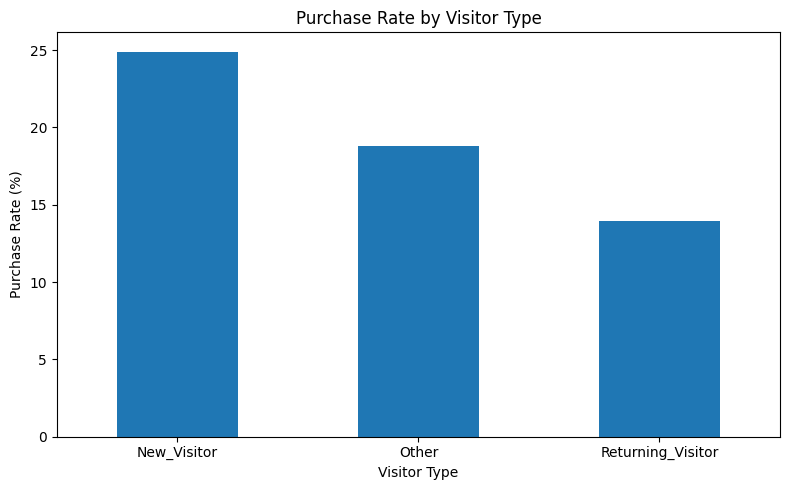

In [ ]:
visitor_conversion[True].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Purchase Rate by Visitor Type')
plt.xlabel('Visitor Type')
plt.ylabel('Purchase Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Key observations from the bar plot and analysis are:

*   **New Visitors**: This group has the highest purchase rate at approximately **24.91%**. This means nearly a quarter of sessions from new visitors result in a purchase. This is a significant conversion rate, especially considering they are new to the site.

*   **Other Visitors**: This smaller category shows a purchase rate of approximately **18.82%**. While lower than new visitors, it's still a respectable conversion rate, suggesting that this group, though undefined, has a reasonable propensity to buy when they do visit.

*   **Returning Visitors**: This group, which constitutes the vast majority of sessions, has the lowest purchase rate at approximately **13.93%**. This indicates that while returning visitors account for the highest *absolute number* of purchases due to their sheer volume, their *conversion efficiency* is lower compared to new and 'other' visitors.

**Overall Implication**:

There is a statistically significant association between `VisitorType` and `Revenue`, as confirmed by the Chi-square test (p-value < 0.05). The bar plot clearly highlights that **New Visitors are the most efficient in terms of converting sessions into purchases**, even though Returning Visitors make up the bulk of overall traffic and total purchases. This suggests that the initial impression or the intent of new visitors arriving at the site might be different, perhaps more focused on making a purchase. For Returning Visitors, while they are loyal, there might be opportunities to improve their conversion rate through targeted strategies, engagement features, or promotions to encourage more frequent or higher-value purchases.

## Conclusion

This exploratory data analysis examined the **Online Shoppers Intention** dataset to identify patterns in website visitor behavior and understand factors associated with whether a browsing session resulted in revenue.

The dataset contains **12,330 sessions and 18 variables**, with no missing values. However, 125 duplicate records were identified, indicating that data cleaning should be considered before further analysis. The target variable, `Revenue`, is also imbalanced: approximately **84.53% of sessions did not generate revenue**, while only **15.47% resulted in a purchase**.

The analysis found that **returning visitors dominate website traffic**, representing approximately 85.57% of sessions. However, new visitors had a higher conversion rate in the analysis, at approximately **24.91%**, compared with **13.93% for returning visitors**. This highlights a difference between traffic volume and conversion behavior.

Product-related engagement was another important pattern. Most sessions involved relatively few product-page visits, while a small number of sessions contained very high levels of browsing activity. Revenue-generating sessions generally showed a higher median number of product-related pages visited than non-revenue sessions, suggesting that deeper product exploration is associated with purchasing behavior. However, the presence of many outliers indicates that product-page engagement alone does not determine whether a purchase occurs.

The analysis also identified a **seasonal pattern** in website activity. May and November recorded some of the highest session volumes, while November showed a particularly strong revenue conversion proportion. Several months, including February and June, showed substantially lower activity and revenue generation. These patterns indicate that purchasing behavior varies across the year.

Finally, `ExitRates` showed a clear difference between revenue and non-revenue sessions in the exploratory analysis. Non-revenue sessions generally exhibited higher exit rates, whereas revenue-generating sessions had lower exit-rate distributions. This suggests that sessions with greater continued engagement are more commonly associated with purchases.

Overall, the EDA indicates that **visitor type, product-related engagement, seasonality, and exit behavior are useful variables for understanding online purchasing sessions**. These findings provide a strong foundation for subsequent feature engineering and predictive modeling, where the imbalanced `Revenue` target and identified outliers should be taken into consideration.